In [14]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.linalg import cholesky # computes upper triangle by default, matches paper
import random
from mpl_toolkits.mplot3d import Axes3D
from embeddingVisualization import plotSPDEmbedding

In [16]:
n = 19
def random_spd_matrix(n):
    A = np.random.rand(n, n)
    return np.dot(A, A.transpose())

In [17]:
wavelet_manifold_output = {
    'delta': torch.tensor([
        random_spd_matrix(n) for i in range(256)
    ]),
    'theta': torch.tensor([
        random_spd_matrix(n) for i in range(256)
    ]),
    'alpha': torch.tensor([
        random_spd_matrix(n) for i in range(256)
    ]),
    'beta': torch.tensor([
        random_spd_matrix(n) for i in range(256)
    ]),
    'gamma': torch.tensor([
        random_spd_matrix(n) for i in range(256)
    ]),
}

combined_manifold_output = torch.tensor([random_spd_matrix(n) for i in range(256)])
# Slow method but don't care since this is just testing
for band, v in wavelet_manifold_output.items():
    print(band, v.shape)
print(combined_manifold_output.shape)

delta torch.Size([256, 19, 19])
theta torch.Size([256, 19, 19])
alpha torch.Size([256, 19, 19])
beta torch.Size([256, 19, 19])
gamma torch.Size([256, 19, 19])
torch.Size([256, 19, 19])


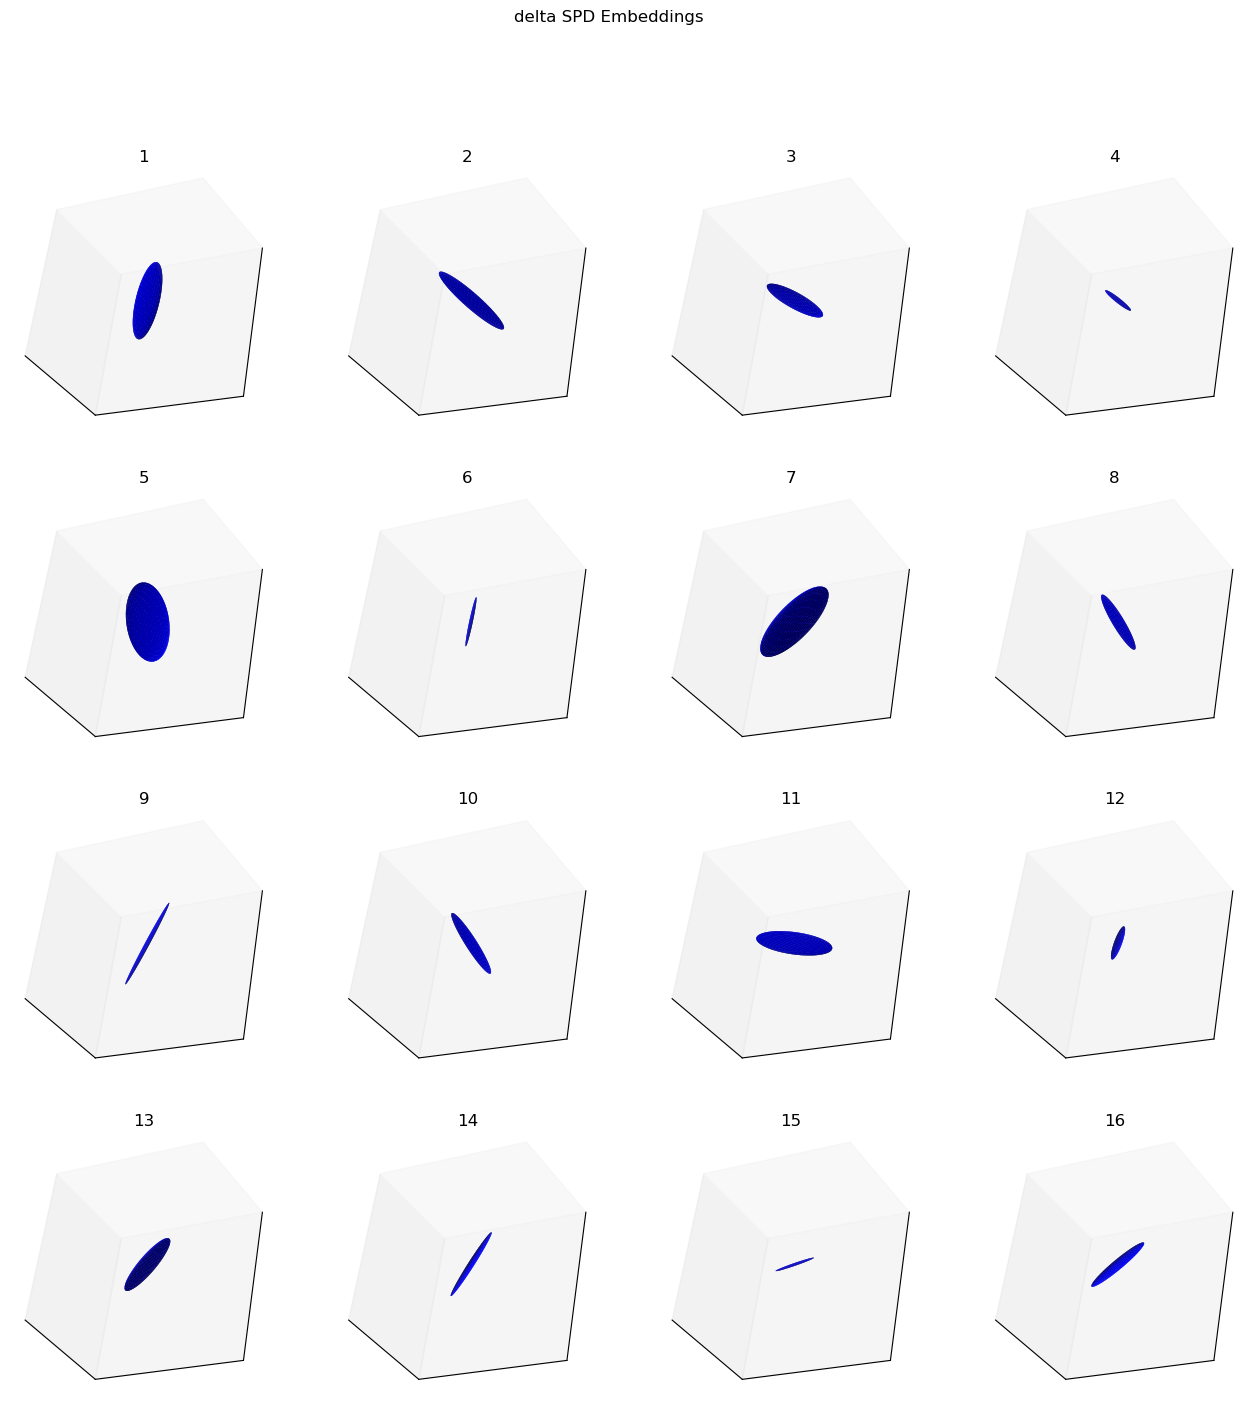

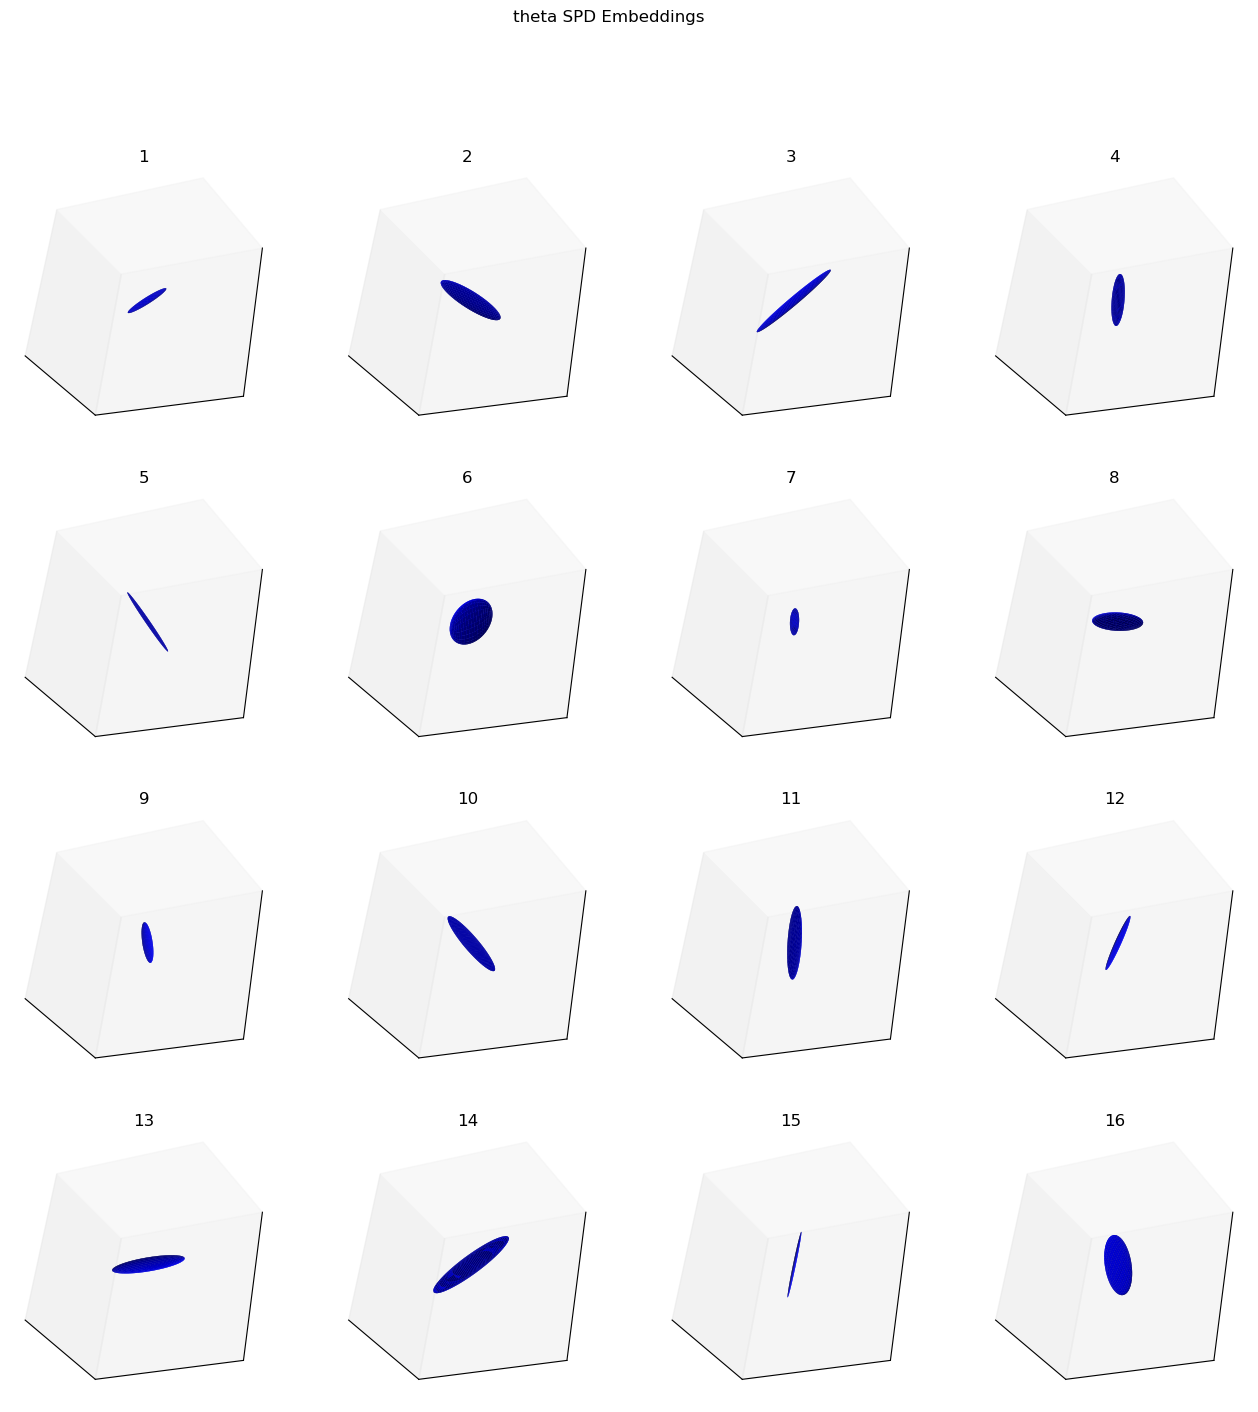

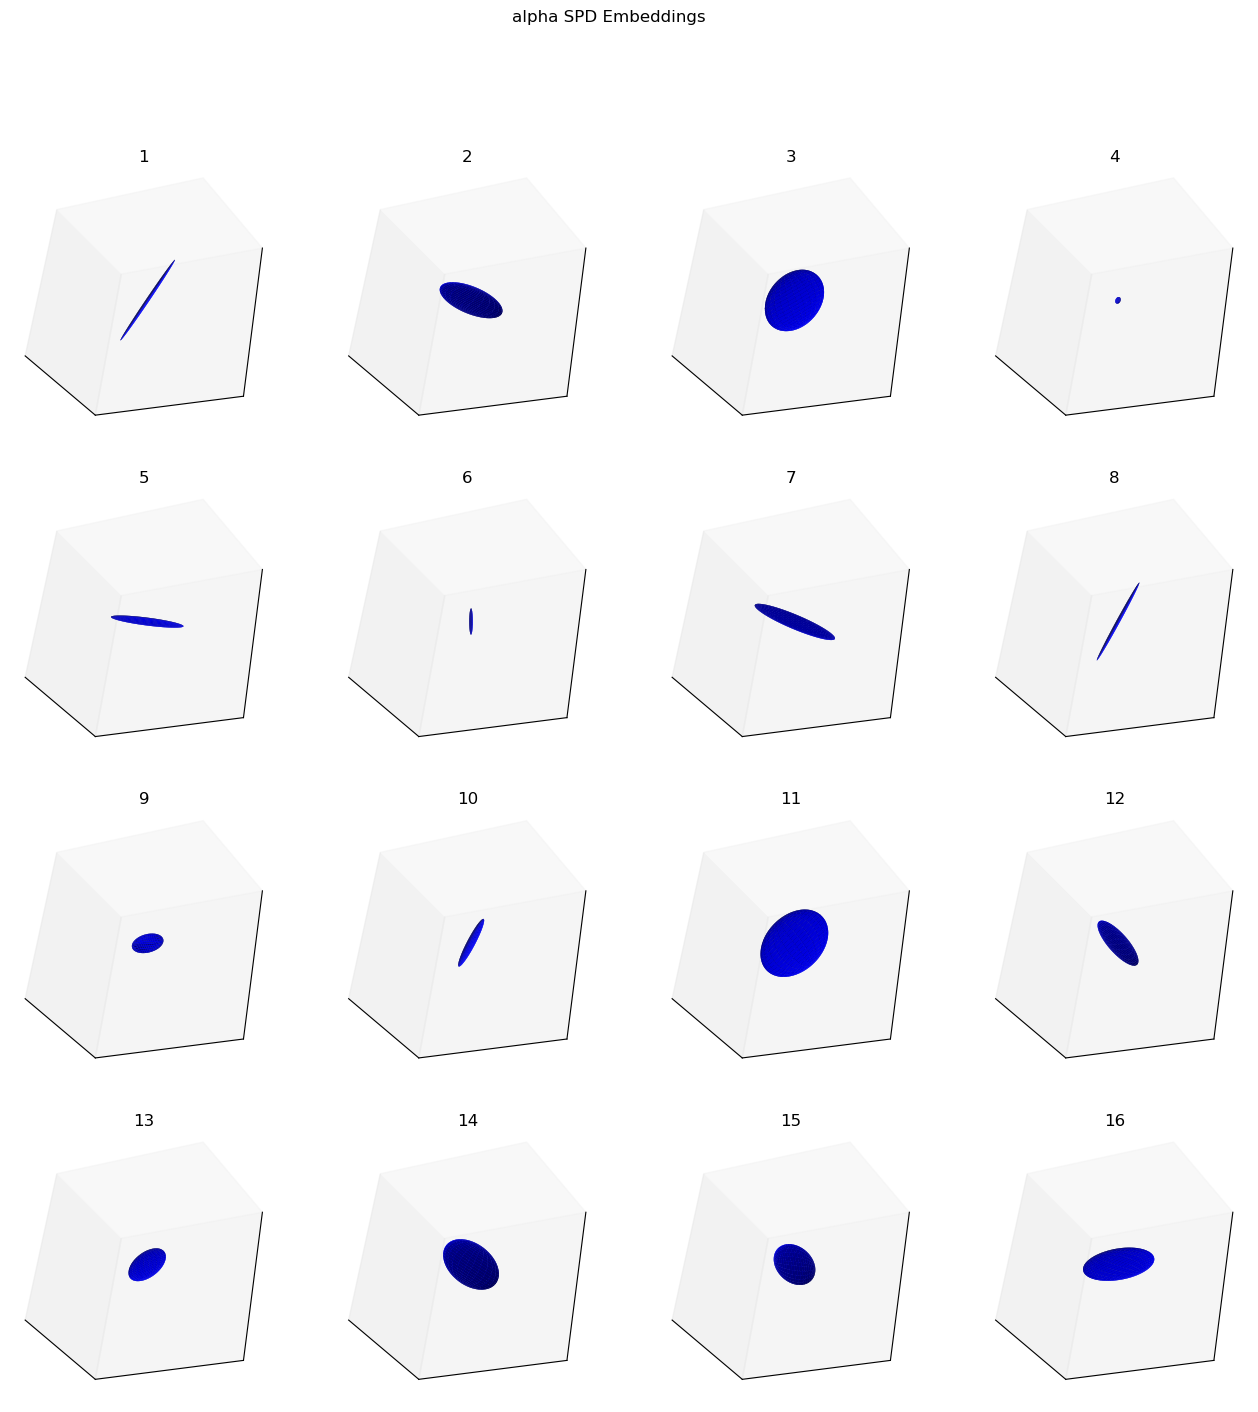

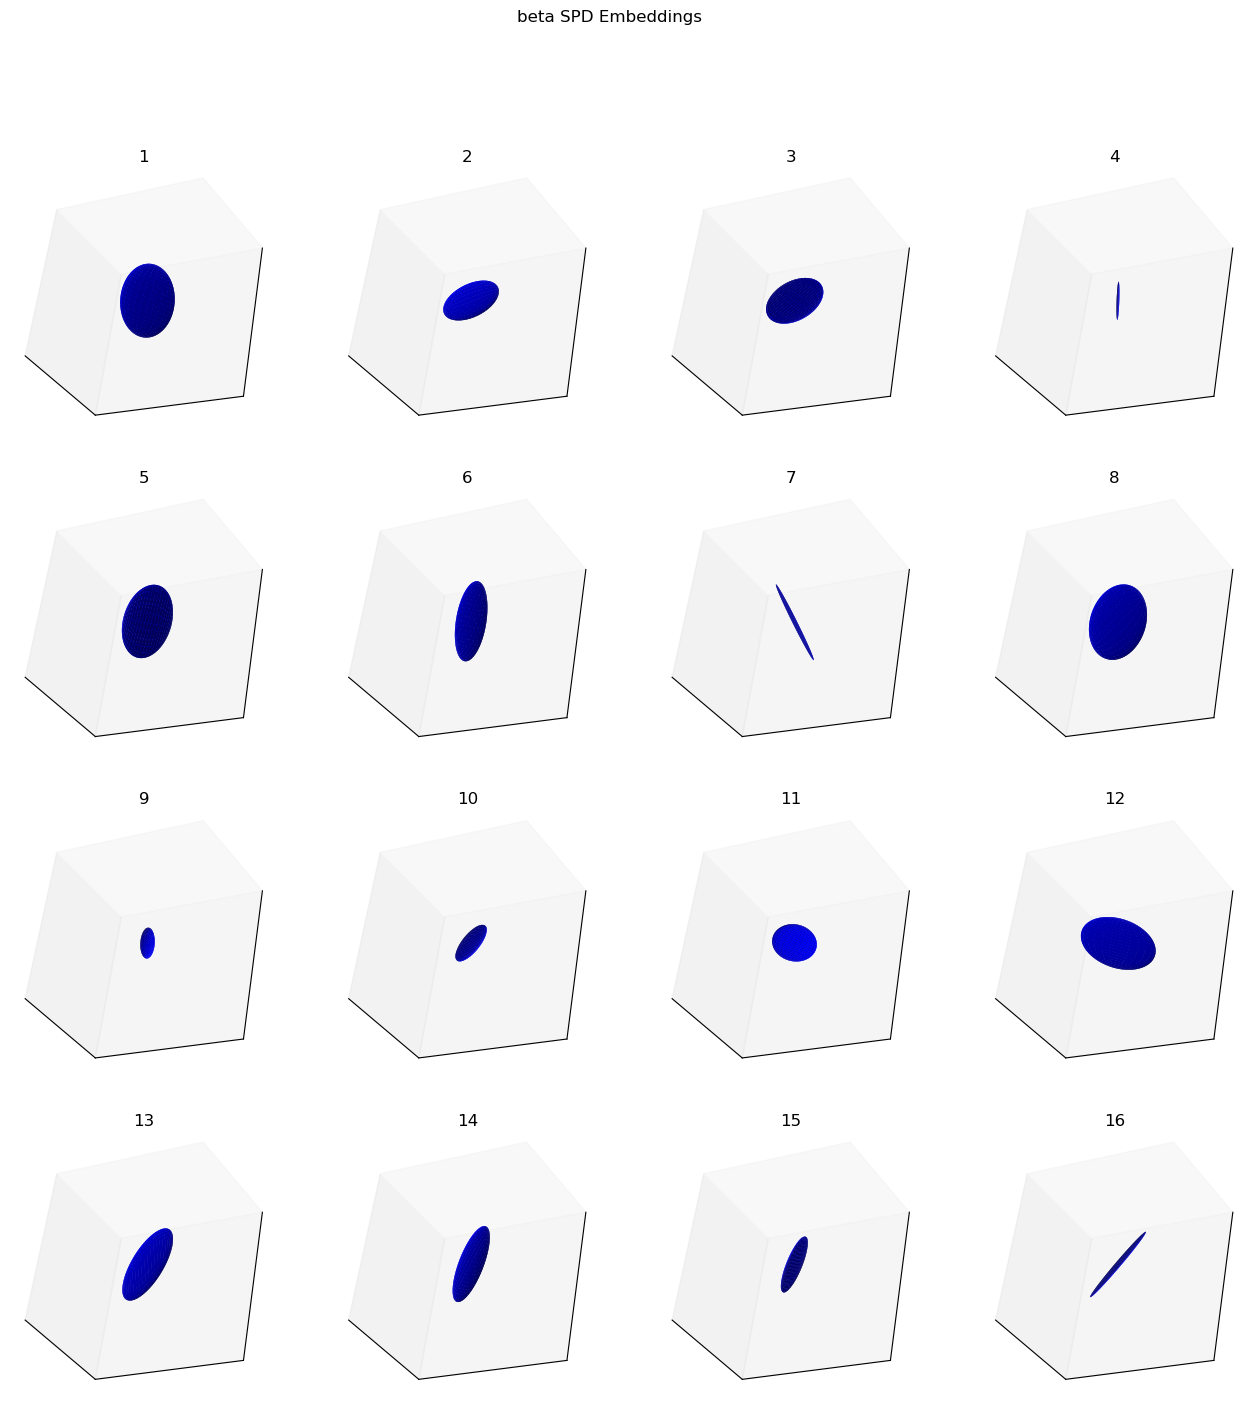

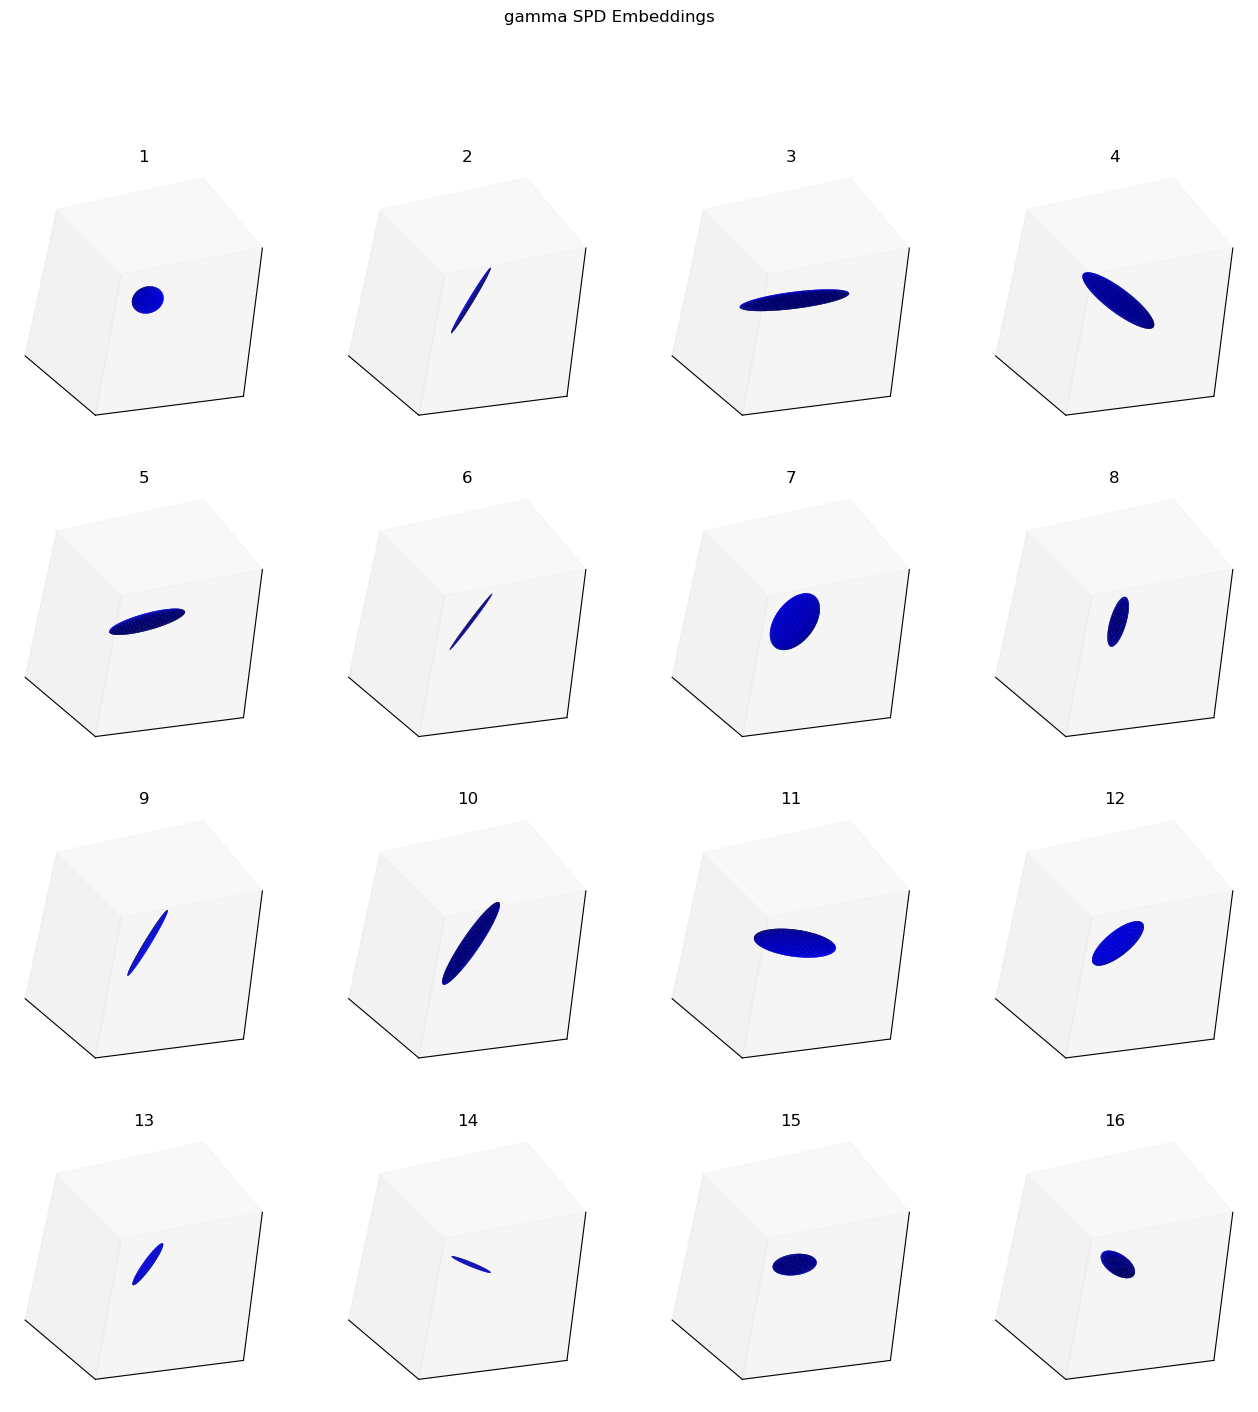

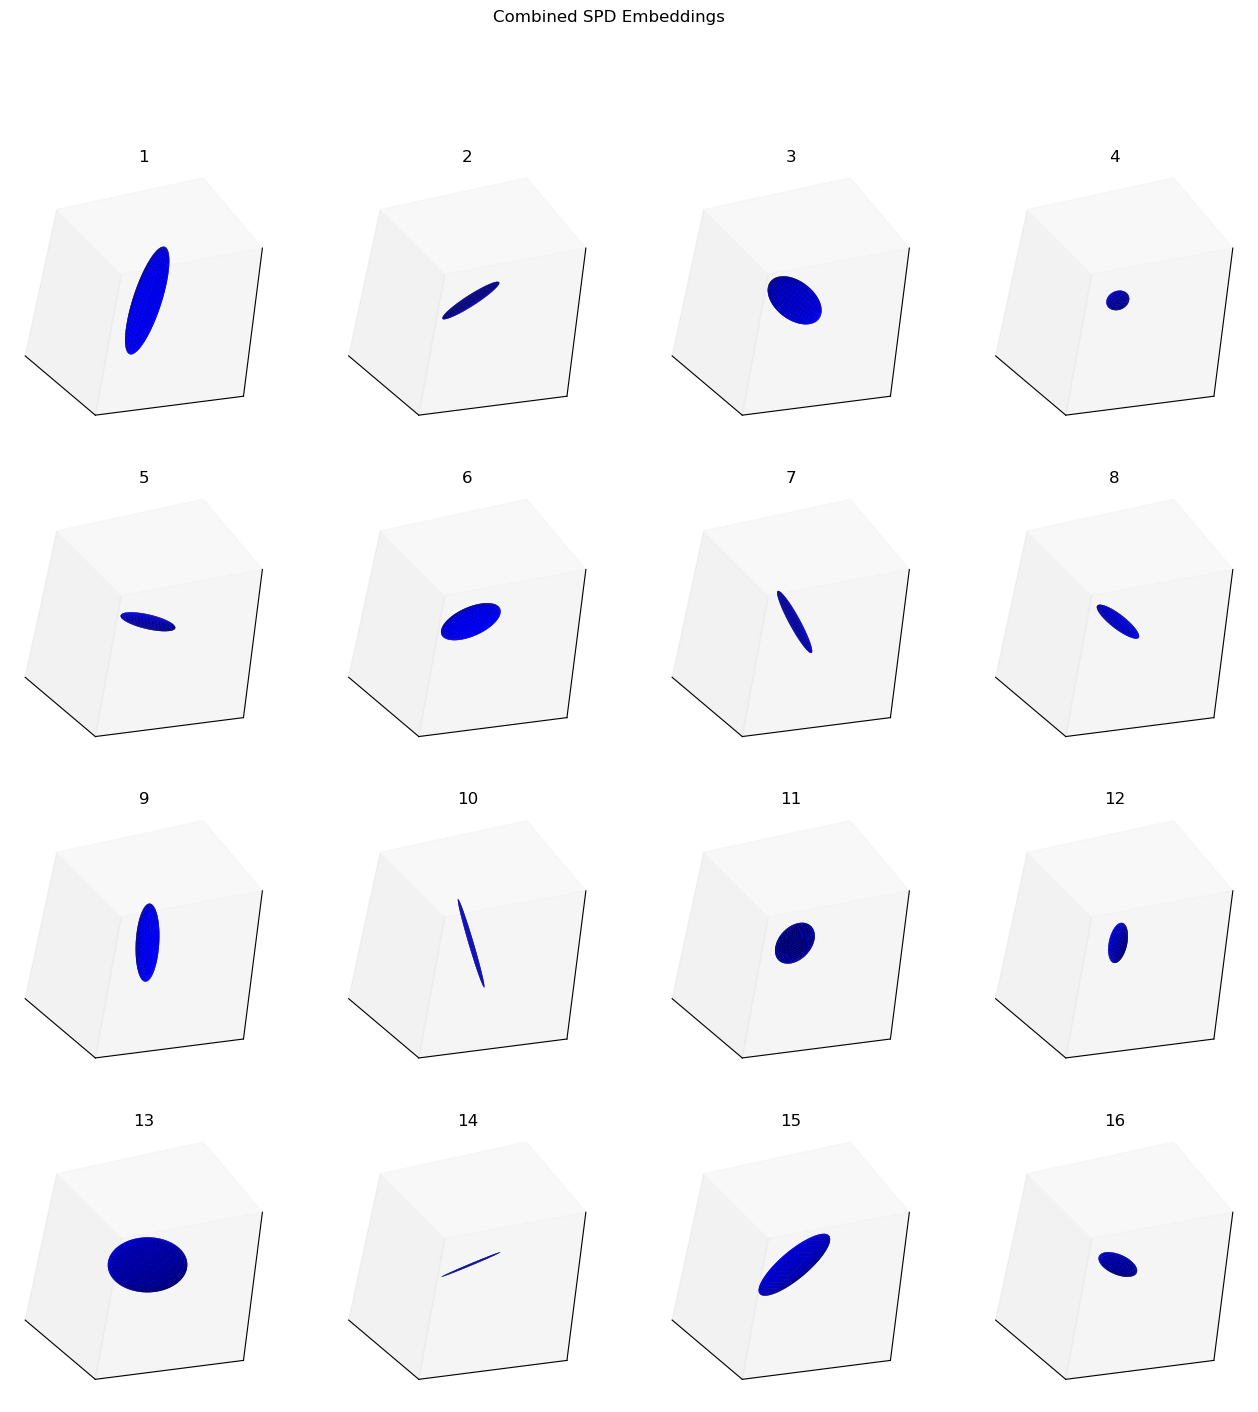

In [18]:
wavelet_figs, combined_fig = plotSPDEmbedding(wavelet_manifold_output, combined_manifold_output)

for band, wavelet_fig in wavelet_figs.items():
    wavelet_fig.savefig(f"./test_figures/{band}_wavelet_fig.png")

combined_fig.savefig(f"./test_figures/combined_fig.png")
plt.show()